# Exploratory Data Analysis (EDA)
German Migration Analysis

Goal:
- Validate cleaned dataset
- Check plausibility
- Explore trends

## Validate cleaned dataset

In [1]:
# 01 Check venv
import sys
print(sys.executable)

/Users/andreasgilling/Documents/GitHub/german-migration-analysis/venv/bin/python


In [2]:
# 02 Conig
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")
sns.set_style("whitegrid")

In [3]:
# 03 Load master dataset
df = pd.read_csv("../data/processed/migration_master_dataset.csv")

df.head()

,year,dimension_type,dimension_value,direction,value
0,1950,global,global,emigration,78148
1,1950,global,global,immigration,96140
2,1951,global,global,emigration,126071
3,1951,global,global,immigration,88349
4,1952,global,global,emigration,135796


In [4]:
df.shape

(10848, 5)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10848 entries, 0 to 10847
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   year             10848 non-null  int64
 1   dimension_type   10848 non-null  str  
 2   dimension_value  10848 non-null  str  
 3   direction        10848 non-null  str  
 4   value            10848 non-null  int64
dtypes: int64(2), str(3)
memory usage: 423.9 KB


In [6]:
# 04 Basic validation

# Missing values
df.isnull().sum()

year               0
dimension_type     0
dimension_value    0
direction          0
value              0
dtype: int64

In [7]:
# Check directions
df["direction"].unique()

<StringArray>
['emigration', 'immigration']
Length: 2, dtype: str

In [8]:
# Check dimension types
df["dimension_type"].unique()

<StringArray>
['global', 'country', 'age']
Length: 3, dtype: str

In [9]:
# Negative values
df[df["value"] < 0]

,year,dimension_type,dimension_value,direction,value


## Global Analysis

In [10]:
# 05 Global Dataframe
df_global = df[df["dimension_type"] == "global"].copy()

df_global.head()

,year,dimension_type,dimension_value,direction,value
0,1950,global,global,emigration,78148
1,1950,global,global,immigration,96140
2,1951,global,global,emigration,126071
3,1951,global,global,immigration,88349
4,1952,global,global,emigration,135796


In [11]:
df_global = df_global[df_global['year'] >= 2000]
df_global.head()

,year,dimension_type,dimension_value,direction,value
100,2000,global,global,emigration,674038
101,2000,global,global,immigration,841158
102,2001,global,global,emigration,606494
103,2001,global,global,immigration,879217
104,2002,global,global,emigration,623255


In [12]:
df_global.shape

(50, 5)

In [13]:
pivot_global = df_global.pivot_table(
    index="year",
    columns="direction",
    values="value",
    aggfunc="sum"
).reset_index()

In [14]:
# Check - each year 2 directions
df_global.groupby("year")["direction"].nunique()

year
2000    2
2001    2
2002    2
2003    2
2004    2
2005    2
2006    2
2007    2
2008    2
2009    2
2010    2
2011    2
2012    2
2013    2
2014    2
2015    2
2016    2
2017    2
2018    2
2019    2
2020    2
2021    2
2022    2
2023    2
2024    2
Name: direction, dtype: int64

In [15]:
pivot_global = df_global.pivot_table(
    index="year",
    columns="direction",
    values="value",
    aggfunc="sum"
).reset_index()

pivot_global.head()

direction,year,emigration,immigration
0,2000,674038,841158
1,2001,606494,879217
2,2002,623255,842543
3,2003,626330,768975
4,2004,697633,780175


In [16]:
# Adding net_migration
pivot_global["net_migration"] = (
    pivot_global["immigration"] - pivot_global["emigration"]
)

In [17]:
# Adding return_rate
pivot_global["return_rate"] = (
    pivot_global["immigration"] / pivot_global["emigration"]
)
pivot_global.head()

direction,year,emigration,immigration,net_migration,return_rate
0,2000,674038,841158,167120,1.247939
1,2001,606494,879217,272723,1.449671
2,2002,623255,842543,219288,1.351843
3,2003,626330,768975,142645,1.227747
4,2004,697633,780175,82542,1.118317


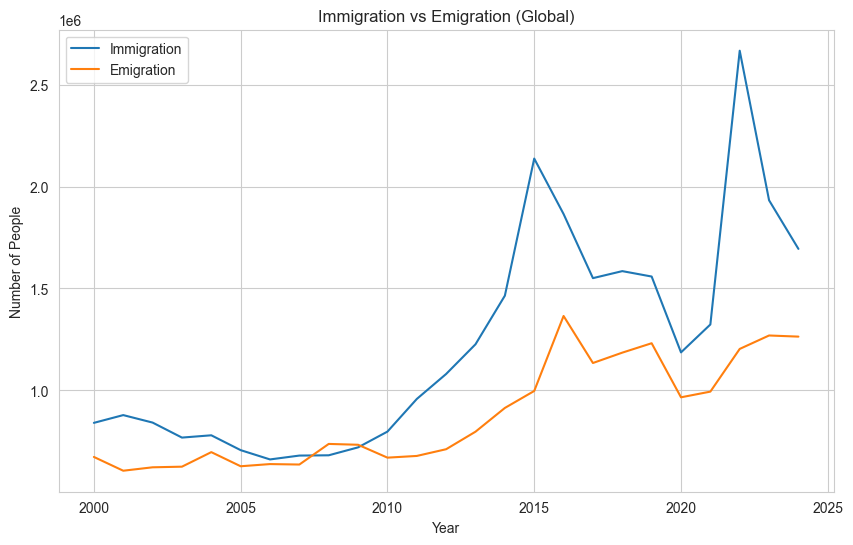

In [18]:
# Plot Global immigration and emigration
plt.figure(figsize=(10,6))
plt.plot(pivot_global["year"], pivot_global["immigration"])
plt.plot(pivot_global["year"], pivot_global["emigration"])

plt.title("Immigration vs Emigration (Global)")
plt.xlabel("Year")
plt.ylabel("Number of People")
plt.legend(["Immigration", "Emigration"])
plt.show()